# Úkol 7


In [6]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


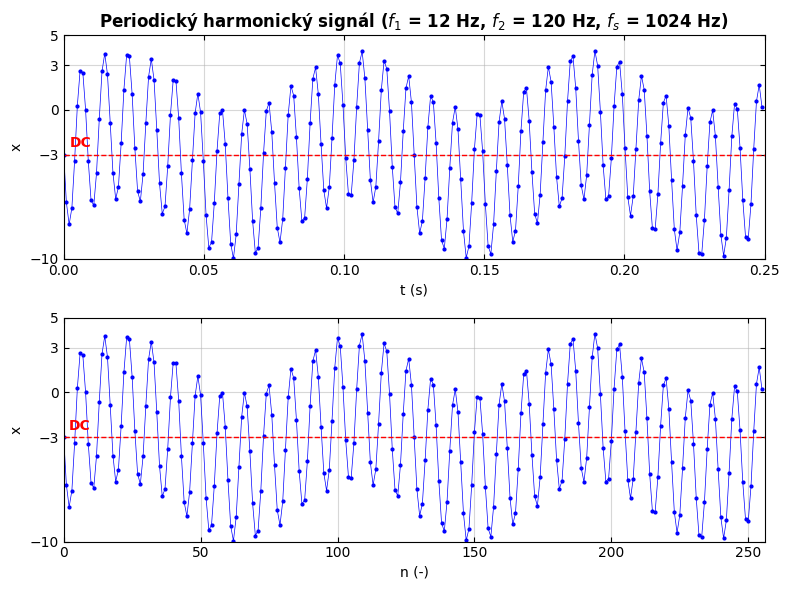

In [7]:
DC = -3
A1 = 2
A2 = -5
f1 = 12
f2 = 120
fs = 1024
N = 256
n = np.arange(N)
t = n / fs

x = DC + A1 * np.sin(2 * np.pi * f1 * n / fs) + A2 * np.sin(2 * np.pi * f2 * n / fs)

plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
ax1.plot(t, x, 'b.-', linewidth=0.5, markersize=4)
ax1.axhline(DC, color='red', linestyle='--', linewidth=1)
ax1.text(0.002, DC + 0.5, 'DC', color='red', fontweight='bold')
ax1.set_title(f'Periodický harmonický signál ($f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_s$ = {fs} Hz)', fontweight='bold')
ax1.set_xlabel('t (s)')
ax1.set_ylabel('x')
ax1.grid(True, alpha=0.5)
ax1.set_ylim(-10, 5)
ax1.set_yticks([-10, -3, 0, 3, 5])
ax1.set_xlim(0, 0.25)
ax1.tick_params(axis='both', direction='in', top=True, right=True)

ax2 = plt.subplot(2, 1, 2)
ax2.plot(n, x, 'b.-', linewidth=0.5, markersize=4)
ax2.axhline(DC, color='red', linestyle='--', linewidth=1)
ax2.text(2, DC + 0.5, 'DC', color='red', fontweight='bold')
ax2.set_xlabel('n (-)')
ax2.set_ylabel('x')
ax2.grid(True, alpha=0.5)
ax2.set_ylim(-10, 5)
ax2.set_yticks([-10, -3, 0, 3, 5])
ax2.set_xlim(0, 256)
ax2.tick_params(axis='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


In [8]:
def compute_dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    n_arr = np.arange(N)
    for k in range(N):
        X[k] = np.sum(x * np.exp(-1j * 2 * np.pi * k * n_arr / N))
    return X

start_dft = time.perf_counter()
X_dft = compute_dft(x)
end_dft = time.perf_counter()
time_dft = end_dft - start_dft

start_fft = time.perf_counter()
X_fft = np.fft.fft(x)
end_fft = time.perf_counter()
time_fft = end_fft - start_fft

time_diff_percent = ((time_dft - time_fft) / time_dft) * 100

print(f"Čas výpočtu DFT: {time_dft:.6f} s")
print(f"Čas výpočtu FFT: {time_fft:.6f} s")
print("-" * 40)
print(f"Délka výpočtu klesla o: {time_diff_percent:.2f} %, což znamená, že FFT je přibližně o {time_diff_percent:.2f} % rychlejší než DFT.")


Čas výpočtu DFT: 0.002791 s
Čas výpočtu FFT: 0.000077 s
----------------------------------------
Délka výpočtu klesla o: 97.24 %, což znamená, že FFT je přibližně o 97.24 % rychlejší než DFT.


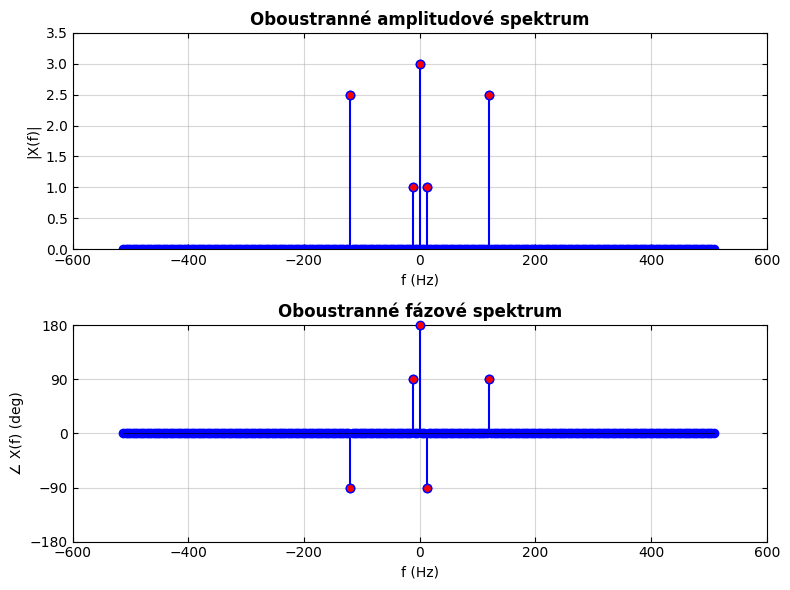

In [9]:
f_double = np.fft.fftfreq(N, 1/fs)
f_double_shifted = np.fft.fftshift(f_double)

X_fft_shifted = np.fft.fftshift(X_fft) / N
mag_double = np.abs(X_fft_shifted)

threshold = 1e-10
phase_double = np.angle(X_fft_shifted, deg=True)
phase_double[mag_double < threshold] = 0

plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
markerline, stemlines, baseline = ax1.stem(f_double_shifted, mag_double, linefmt='b-', basefmt='k-')
stemlines.set_zorder(2)
baseline.set_linewidth(0.5)
significant = mag_double > threshold
ax1.scatter(f_double_shifted[significant], mag_double[significant], facecolors='red', edgecolors='blue', zorder=3)
ax1.set_title('Oboustranné amplitudové spektrum', fontweight='bold')
ax1.set_xlabel('f (Hz)')
ax1.set_ylabel('|X(f)|')
ax1.grid(True, alpha=0.5)
ax1.set_xlim(-600, 600)
ax1.set_ylim(0, 3.5)
ax1.tick_params(axis='both', direction='in', top=True, right=True)

ax2 = plt.subplot(2, 1, 2)
markerline, stemlines, baseline = ax2.stem(f_double_shifted, phase_double, linefmt='b-', basefmt='k-')
stemlines.set_zorder(2)
baseline.set_linewidth(0.5)
significant_phase = mag_double > threshold
ax2.scatter(f_double_shifted[significant_phase], phase_double[significant_phase], facecolors='red', edgecolors='blue', zorder=4, clip_on=False)
ax2.set_title('Oboustranné fázové spektrum', fontweight='bold')
ax2.set_xlabel('f (Hz)')
ax2.set_ylabel('∠ X(f) (deg)')
ax2.grid(True, alpha=0.5)
ax2.set_xlim(-600, 600)
ax2.set_ylim(-180, 180)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.tick_params(axis='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


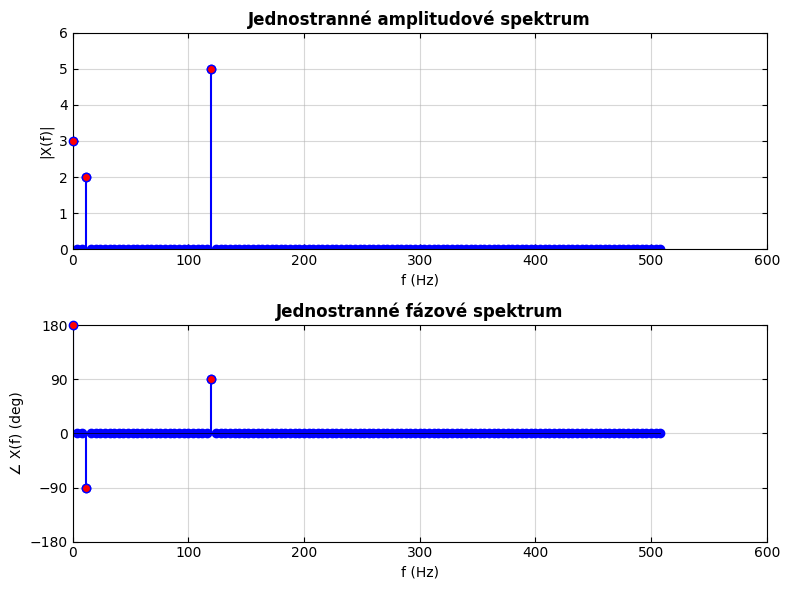

In [10]:
half_N = N // 2
f_single = f_double[:half_N]

mag_single = np.abs(X_fft[:half_N]) / N
mag_single[1:] = 2 * mag_single[1:]

phase_single = np.angle(X_fft[:half_N], deg=True)
phase_single[mag_single < threshold] = 0

plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
markerline, stemlines, baseline = ax1.stem(f_single, mag_single, linefmt='b-', basefmt='k-')
stemlines.set_zorder(2)
baseline.set_linewidth(0.5)
significant_single = mag_single > threshold
ax1.scatter(f_single[significant_single], mag_single[significant_single], facecolors='red', edgecolors='blue', zorder=4, clip_on=False)
ax1.set_title('Jednostranné amplitudové spektrum', fontweight='bold')
ax1.set_xlabel('f (Hz)')
ax1.set_ylabel('|X(f)|')
ax1.grid(True, alpha=0.5)
ax1.set_xlim(0, 600)
ax1.set_ylim(0, 6)
ax1.set_yticks(range(0, 7))
ax1.tick_params(axis='both', direction='in', top=True, right=True)

ax2 = plt.subplot(2, 1, 2)
markerline, stemlines, baseline = ax2.stem(f_single, phase_single, linefmt='b-', basefmt='k-')
stemlines.set_zorder(2)
baseline.set_linewidth(0.5)
significant_phase_single = mag_single > threshold
ax2.scatter(f_single[significant_phase_single], phase_single[significant_phase_single], facecolors='red', edgecolors='blue', zorder=4, clip_on=False)
ax2.set_title('Jednostranné fázové spektrum', fontweight='bold')
ax2.set_xlabel('f (Hz)')
ax2.set_ylabel('∠ X(f) (deg)')
ax2.grid(True, alpha=0.5)
ax2.set_xlim(0, 600)
ax2.set_ylim(-180, 180)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.tick_params(axis='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


## Komentář
Nejprve jsem importoval nezbytné knihovny. Následně jsem definoval základní parametry signálu: stejnosměrnou složku $DC = -3$, amplitudy harmonických složek $A_1 = 2$, $A_2 = -5$ a jejich příslušné frekvence $f_1 = 12$ Hz, $f_2 = 120$ Hz. Poté jsem vytvořil funkci reprezentující původní diskrétní signál $x[n]$ rozšířený na interval odpovídající délce sekvence $N = 256$ vzorků, aby pokryl požadované časové okno. Vzorkovací frekvenci $f_s = 1024$ Hz jsem zvolil přesně podle zadání, aby zajistila plynulé a přesné vykreslení všech následných průběhů.

Algoritmus pro výpočet koeficientů diskrétní Fourierovy transformace jsem realizoval pomocí přímého výpočtu definičního vztahu sumace přes všechny vzorky. Následně jsem využil optimalizovanou funkci z knihovny NumPy, která na základě algoritmu FFT provádí analýzu $x[n]$ postupně pro porovnání a exaktní měření doby obou výpočtů.

Pro názornou vizualizaci jsem vygeneroval první dva grafy zobrazující průběhy původního generovaného signálu. Vizuálním porovnáním jsem potvrdil, že se střední hodnota signálu přesně shoduje se zadaným stejnosměrným posunem $DC = -3$, přičemž je zřetelně pozorovatelný projev obou harmonických složek v závislosti na čase a počtu vzorků. Poté jsem provedl měření doby výpočtu pro oba algoritmy a porovnal jejich efektivitu, přičemž jsem zaznamenal výrazné zrychlení díky využití FFT oproti přímému výpočtu.

Nakonec jsem pro detailní analýzu vypočtené hodnoty oboustranného spektra a odvozené hodnoty jednostranného spektra (včetně jejich velikosti a fáze) formátoval do dvou přehledných sad grafů. První sada grafů zobrazuje hodnoty oboustranného amplitudového a fázového spektra, druhá sada grafů pak přehledně verifikuje odvozené jednostranné amplitudové a fázové spektrum (s korektním vynásobením střídavých složek). Fázi jsem pro lepší čitelnost v grafu převedl do stupňů, čímž jsem ověřil správnost frekvenční reprezentace signálu.
